In [1]:
import pandas as pd
import numpy as np

# load cleaned data

df_cleaned = pd.read_csv('data/data_cleaned.csv', low_memory=False)
df_cleaned.shape

(3596, 12)

In [2]:
print(df_cleaned.head().to_string())

                               id        date                   titulaire-liste titulaire-profession titulaire-age-calcule titulaire-sexe departement-insee                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [3]:
df_cleaned.columns

Index(['id', 'date', 'titulaire-liste', 'titulaire-profession',
       'titulaire-age-calcule', 'titulaire-sexe', 'departement-insee', 'text',
       'word_count', 'year', 'profession_clean', 'party_clean'],
      dtype='str')

In [4]:
df_cleaned.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,profession_clean,party_clean
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,Other,Other
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,Health,Union pour une nouvelle majorité
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,Health,Union pour une nouvelle majorité
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,Education,Other
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,Other,Union pour une nouvelle majorité


In [5]:
df_cleaned['word_count'].describe()

count    3596.000000
mean      637.065072
std       289.338109
min       130.000000
25%       464.000000
50%       555.000000
75%       784.000000
max      2765.000000
Name: word_count, dtype: float64

In [6]:
df_cleaned["party_clean"].value_counts().head(15)

party_clean
Other                                          864
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Liste entente populaire et nationale           322
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Liste d'entente populaire et nationale         128
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64

In [7]:
df_cleaned["profession_clean"].value_counts()

profession_clean
Other          1454
Education       617
Health          303
Business        300
Technical       278
Law             195
Worker          188
Agriculture     111
Political        95
Media            55
Name: count, dtype: int64

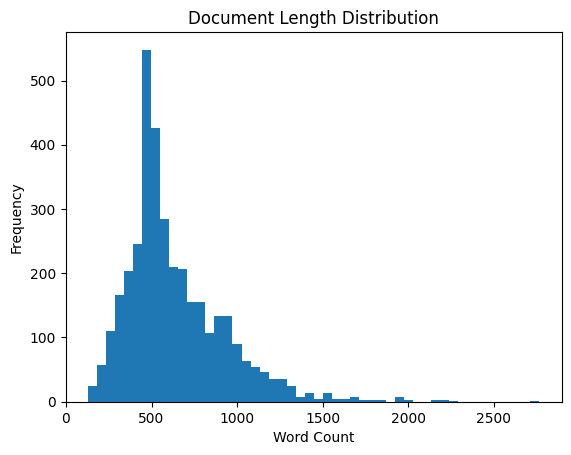

In [8]:
import matplotlib.pyplot as plt

plt.hist(df_cleaned['word_count'], bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

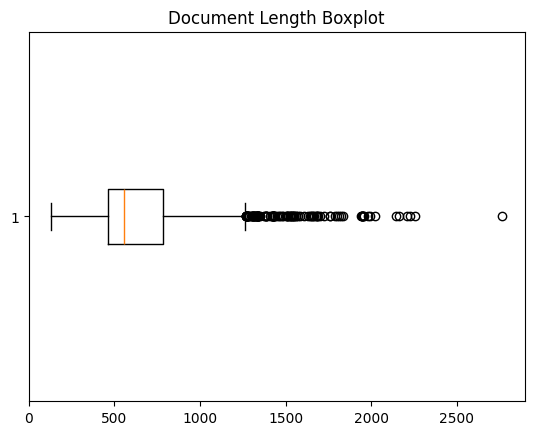

In [9]:
plt.boxplot(df_cleaned['word_count'], vert=False)
plt.title("Document Length Boxplot")
plt.show()

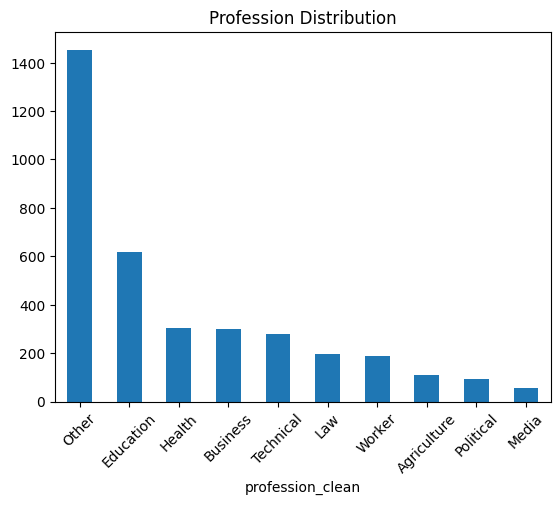

In [10]:
df_cleaned['profession_clean'].value_counts().plot(kind='bar')
plt.title("Profession Distribution")
plt.xticks(rotation=45)
plt.show()

In [11]:
import nltk
nltk.download('stopwords', download_dir='./nltk_data')

[nltk_data] Downloading package stopwords to ./nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import numpy as np

# Load French stopwords
french_stopwords = stopwords.words('french')

vectorizer = CountVectorizer(
    stop_words=french_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # only words longer that letters and no numbers to prevent temporal when modeling
    max_df=0.95,
    min_df=20
)

# Fit and transform
X = vectorizer.fit_transform(df_cleaned['text'])

# Get words and counts
words = vectorizer.get_feature_names_out()
word_counts = np.array(X.sum(axis=0)).flatten()

# Combine and sort
freq = [(word, int(word_counts[i])) for i, word in enumerate(words)]
freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)

# Top 30
freq_sorted[:30]

[('plus', 7659),
 ('france', 7629),
 ('politique', 7399),
 ('ans', 6157),
 ('circonscription', 5902),
 ('candidat', 5399),
 ('juin', 5342),
 ('tous', 5328),
 ('gauche', 5079),
 ('nationale', 4777),
 ('majorité', 4552),
 ('national', 4475),
 ('droite', 4368),
 ('vie', 4332),
 ('être', 4277),
 ('pays', 4250),
 ('français', 4249),
 ('comme', 4209),
 ('faire', 4079),
 ('parti', 4038),
 ('sans', 3907),
 ('union', 3873),
 ('candidats', 3866),
 ('contre', 3796),
 ('cette', 3764),
 ('faut', 3668),
 ('nouvelle', 3630),
 ('toutes', 3572),
 ('avenir', 3568),
 ('vote', 3507)]

In [13]:
top_parties

NameError: name 'top_parties' is not defined

In [ ]:
top_parties = df_cleaned['party_clean'].value_counts().head(6).index

In [ ]:
top_parties = df_cleaned['party_clean'].value_counts().head(6).index
df_top = df_cleaned[df_cleaned['party_clean'].isin(top_parties)]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words=french_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # removes numbers & short tokens
    max_df=0.9,
    min_df=10
)

X_tfidf = tfidf.fit_transform(df_top['text'])
terms = tfidf.get_feature_names_out()

In [ ]:
import numpy as np

for party in top_parties:
    idx = (df_top['party_clean'] == party).values
    mean_tfidf = X_tfidf[idx].mean(axis=0)
    sorted_indices = np.argsort(mean_tfidf.A1)[::-1][:15]
    print("\nParty:", party)
    print([terms[i] for i in sorted_indices])


Party: Other
['gauche', 'politique', 'plus', 'droite', 'tous', 'faut', 'ans', 'majorité', 'parti', 'sans', 'france', 'vie', 'communiste', 'contre', 'faire']

Party: Entente des écologistes
['écologie', 'ecologistes', 'entente', 'verts', 'écologistes', 'environnement', 'ecologie', 'vie', 'generation', 'peu', 'chance', 'génération', 'politique', 'nouvelle', 'assemblée']

Party: Union pour une nouvelle majorité
['majorité', 'nouvelle', 'union', 'liberté', 'france', 'juin', 'plus', 'socialiste', 'communiste', 'changement', 'parti', 'non', 'tous', 'société', 'politique']

Party: Liste entente populaire et nationale
['front', 'national', 'vote', 'udf', 'rpr', 'nationale', 'vive', 'force', 'convictions', 'leurs', 'suppression', 'jusqu', 'avenir', 'ici', 'députés']

Party: Union du rassemblement et du centre
['centre', 'union', 'conseiller', 'rassemblement', 'maire', 'juin', 'tous', 'france', 'général', 'président', 'plus', 'ans', 'ouverture', 'député', 'candidat']

Party: Majorité présidenti